# Лабораторная работа №1

## Загрузка и подготовка данных

Импорт необходимых библиотек для этого этапа.

In [33]:
import pandas as pd
import numpy as np

Чтение датасета.

In [34]:
df = pd.read_csv("data/student_lifestyle_100k.csv")

Посмотрим заголовок таблицы и первые строки.

In [35]:
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


Посмотрим информацию о data frame.

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB


Проверим на дубликаты и на количество пропущенных значений.

In [37]:
df.duplicated().sum()

np.int64(0)

Видим: в df нет дубликатов. Никаких дейтсвий по их очистке делать не требуется. Запомним этот факт.

Теперь проверим на количество пропусков в каждой колонке.

In [38]:
df.isna().sum() # axis = 0 => сумма по столбцам

Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64

Видим: в df нет ни одного пропуска во всех колонках. Запомним этот факт, и далее опустим все проверки на пропуски.

Удалим неинтересующую нас колонку 'Student_ID', а остальные для удобства переименуем. 

In [39]:
df = df.drop(['Student_ID'], axis=1)

df = df.rename(columns={
    "Department": "Profile",
    "Sleep_Duration": "Sleep",
    "Study_Hours": "Study",
    "Social_Media_Hours": "Media",
    "Physical_Activity": "Sport",
    "Stress_Level": "Stress"
})

Также заметим: значения в новой колонке 'Spor' приведены как минуты в неделю. Для удобства оанализа преобразуем их к часы в день. Тогда колонки 'Sport', 'Media', 'Sleep', 'Study' будут иметь одинаковые единицы измерения.

In [42]:
df["Sport"] = df["Sport"] / (60 * 7)

In [43]:
df.head()

,Age,Gender,Profile,CGPA,Sleep,Study,Media,Sport,Stress,Depression
0,22,Female,Science,3.50,7.3,3.3,3.4,0.271429,5,False
1,20,Male,Engineering,2.72,5.5,7.2,6.0,0.338095,2,False
2,20,Male,Medical,3.01,5.4,2.3,1.8,0.326190,3,False
3,21,Male,Engineering,3.63,8.1,2.0,4.6,0.309524,3,False
4,19,Male,Arts,3.14,6.8,2.6,4.3,0.009524,6,False


Теперь проверим, что в данных нет логических ошибок. Для удобства вставлю исходное описание:
| Название столбца         | Описание                                                        | Тип данных          |
|--------------------------|-----------------------------------------------------------------|---------------------|
| Age                      | Возраст студента (18-24)                                        | Целое число         |
| Gender                   | Пол студента (мужской/женский)                                  | Строка              |
| Department               | Область обучения (инженерное дело, бизнес, искусство и т. д.)    | Строка              |
| CGPA                     | Средний балл успеваемости (0.0 - 4.0)                           | Число с плавающей запятой |
| Sleep_Duration           | Среднее количество часов сна в сутки                            | Число с плавающей запятой |
| Study_Hours              | Среднее количество часов, затраченных на учебу в день           | Число с плавающей запятой |
| Social_Media_Hours       | Среднее количество часов, проведённых в социальных сетях в день | Число с плавающей запятой |
| Physical_Activity        | Среднее количество минут физической активности в неделю         | Целое число         |
| Stress_Level             | Уровень стресса, по самооценке (шкала 0-10)                     | Целое число         |
| Depression               | Состояние психического здоровья (True = Вероятная депрессия, False = Здоровый) | Логическое значение |

In [66]:
# Все значения в полях колонок отражающих время - неотрицательные
negative_rows = (df["Study"] < 0) | (df["Sleep"] < 0) | (df["Media"] < 0) | (df["Sport"] < 0)

print("Строк с отрицательным временем нет: ", negative_rows.sum() == 0)

# Проверим что нету строк со значениями по времени > 15ч
extrime_rows = (df["Study"] > 15) | (df["Sleep"] > 15) | (df["Media"] > 15) | (df["Sport"] > 15)

print("Строк с экстримальм временем (> 15ч) нет: ", extrime_rows.sum() == 0)

# Проверим, что в колонке со значем пол только 2 значения
unique_gender = df["Gender"].unique()
print("Пол только м. и ж.: ", len(unique_gender) == 2)

# Проверим, что 0 < CGPA < 4
row_error_cgpa = (df["CGPA"] < 0) | (df["CGPA"] > 4)
print("Значения CGPA лежат в [0, 4]: ", row_error_cgpa.sum() == 0)

# Проверим, что возраст студентов лежит в [18, 24]
row_error_age = (df["Age"] < 18) | (df["Age"] > 24)
print("Возраст студентов лежит в [18, 24]: ", row_error_cgpa.sum() == 0)

# Проверим, сколько будет сумма часов указанных в сутки для каждого студенка
sum_hours_per_day = df["Sleep"] + df["Study"] + df["Media"] + df["Sport"]
hours_unknown = np.zeros(len(sum_hours_per_day), dtype=float) * 24 - sum_hours_per_day

print("Min указанные часы в день: ", min(sum_hours_per_day))
print("Max указанные часы в день: ", max(sum_hours_per_day))

extreme_sum_hours_per_day = sum_hours_per_day > 24
print("Количество студентов с сумой времени > 24ч в день:", extreme_sum_hours_per_day.sum())
# Тут есть значение > 27ч, нижи попробую предположить почему это могло произойти

# Проверим, что уровень стресса лежит в [0, 10]
row_error_stress = (df["Stress"] < 0) | (df["Stress"] > 10)
print("Ошибок в колонке Stress нет: ", row_error_stress.sum() == 0)

Строк с отрицательным временем нет:  True
Строк с экстримальм временем (> 15ч) нет:  True
Пол только м. и ж.:  True
Значения CGPA лежат в [0, 4]:  True
Возраст студентов лежит в [18, 24]:  True
Min указанные часы в день:  3.6
Max указанные часы в день:  27.361904761904764
Количество студентов с сумой времени > 24ч в день: 109
Ошибок в колонке Stress нет:  True


Я обнаружил, что у ряда студентов сумма активностей превышает 24 часа (max = 27.36). Я решил оставить эти данные, предполагая возможность совмещения активностей (например, прослушивание аудиокниг во время занятий спортом), так как отклонение не является критическим (менее 15% от 24 часов), но стоить иметь ввиду этот факт. Я не буду считать это ошибкой, и не буду заменять время или же удалять эти строки.

## Разведочный анализ даннх (EDA)

Импортируем дополнительно библиотеки для этого этапа.

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

Создам копию data frame, чтобы не влиять на исходные данные во время EDA.

In [73]:
eda_df = df.copy()

### Анализ целевых переемнныхпеременных

Гистрограмма для CGPA:

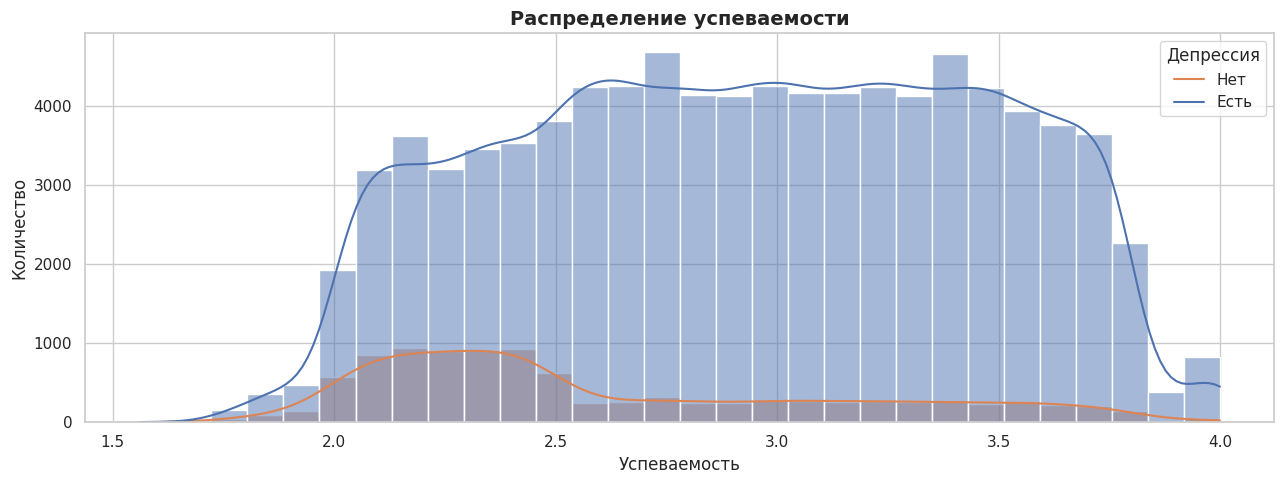

In [143]:
plt.figure(figsize=(13, 5))

sns.histplot(data=eda_df, x="CGPA", kde=True, bins=30, hue="Depression",
        )

plt.xlabel("Успеваемость")
plt.ylabel("Количество")
plt.title("Распределение успеваемости", fontsize=14, fontweight="bold")
plt.legend(title='Депрессия', labels=['Нет', 'Есть'])

plt.tight_layout()
plt.show()

Видим, что распределение по успеваемости имеет форму трапеции, с длинным платом, сильных перекосов не видно. Причём, видно, что люди с депрессией чаще имеют более низкую успеваемость и людей с депрессией сильно меньше чем людей без неё, но это первичный анализ. Более подробно это рассмотрим на следующих графиках.

Countplot для Depression:

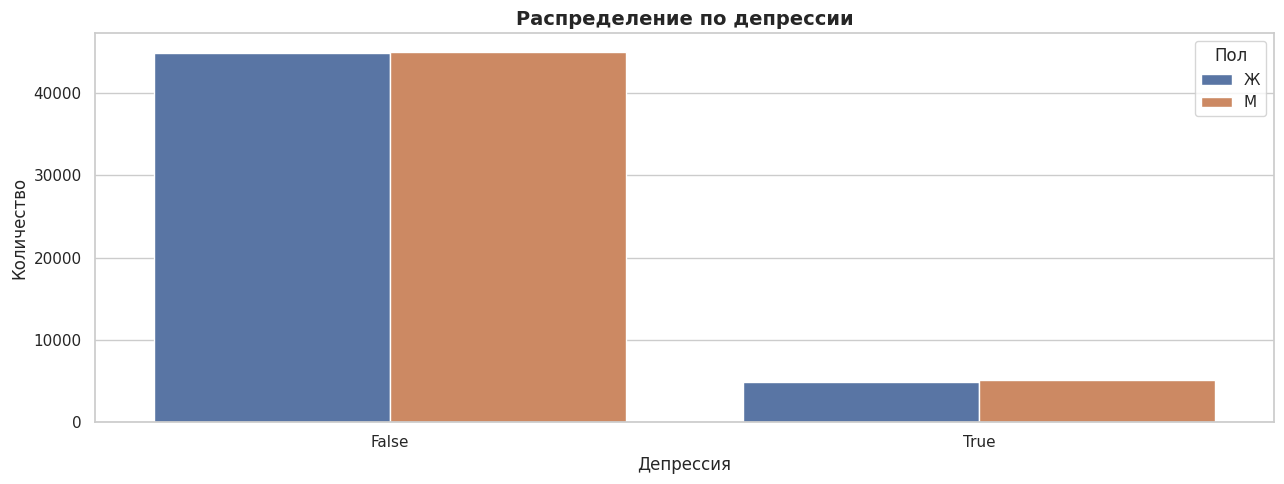

Людей без депрессии: 89938 (89.938%)
Людей с депрессией: 10062 (10.062%)


In [151]:
plt.figure(figsize=(13, 5))

sns.countplot(data=eda_df, x="Depression", hue="Gender", )

plt.xlabel("Депрессия")
plt.ylabel("Количество")
plt.title("Распределение по депрессии", fontsize=14, fontweight="bold")
plt.legend(title='Пол', labels=['Ж', 'М'])

plt.tight_layout()
plt.show()

has_depression = sum(eda_df["Depression"])
has_not_deperssion = len(eda_df[["Depression"]]) - has_depression

depression_persent = 100 * has_depression / len(eda_df[["Depression"]])
not_depression_persent = 100 - depression_persent

print(f"Людей без депрессии: {has_not_deperssion} ({not_depression_persent}%)")
print(f"Людей с депрессией: {has_depression} ({depression_persent}%)")

Наблюдаем, что людей с депрессией сильно меньше чем людей без ней, при этом не видно зависимости от пола. Людей с депрессией примерно 10%, людей без неё примерно 90%.

### Анализ признаков

#### Анализ числовых признаков